# Lab: Modelling & Model Lifecycle — Predicting Plant Production (GIST Steel Dataset)

---

## Learning Outcomes

By completing this lab, you will be able to:

- Prepare and analyse a dataset for modelling.  
- Train and evaluate regression models.  
- Apply cross-validation and hyperparameter tuning using scikit-learn.  
- Track experiments and store models using MLflow and/or Optuna.  
- Reflect on the practical aspects of managing the ML lifecycle.

---



## 1. Data Setup and Exploration
*Estimated time: 30–40 min*

### Objective  
Understand the dataset structure and the target variable (“plant-level production”).

---

### **Task 1.1 – Load and Inspect Data**
- Load the GIST Steel dataset. 
- Display basic info (shape, column names, missing values, and data types).  
- Identify the target variable (production) and key features (capacity, ...).

> *Markdown prompt:*  
Describe any patterns or potential data quality issues you notice. Which variables might strongly influence production?

---

In [564]:
import pandas as pd

# Set the file path
file_path = "Plant-level-data-Global-Iron-and-Steel-Tracker.xlsx"

# Load all necessary sheets
sheets = ["Plant data", "Plant capacities and status", "Plant production"]
dfs = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in sheets}

# Check that 'Plant ID' exists in each dataframe
for name, df in dfs.items():
    if 'Plant ID' not in df.columns:
        raise ValueError(f"'Plant ID' missing in sheet '{name}'")

# Function to select columns to merge
def select_merge_cols(base_df, new_df):
    cols = [col for col in new_df.columns if col not in base_df.columns or col == 'Plant ID']
    return new_df[cols]

# Merge the DataFrames with inner join to keep only the factories present in the 3 datasets
df_merged = dfs["Plant data"]
for sheet in sheets[1:]:
    df_merged = pd.merge(df_merged, 
                         select_merge_cols(df_merged, dfs[sheet]), 
                         on='Plant ID', 
                         how='inner')

In [565]:
# Display information about the merged dataset
print("=== Merged Dataset Information ===")
print(f"Total number of rows: {df_merged.shape[0]}")
print(f"Total number of columns: {df_merged.shape[1]}")
print(f"Number of unique Plant IDs: {df_merged['Plant ID'].nunique()}")
print(f"Number of duplicate Plant IDs: {df_merged.duplicated(subset='Plant ID').sum()}")

# Preview the dataset
print("\nPreview of the first rows:")
df_merged.head()

=== Merged Dataset Information ===
Total number of rows: 3243
Total number of columns: 61
Number of unique Plant IDs: 476
Number of duplicate Plant IDs: 2767

Preview of the first rows:


,Plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM ID,Owner PermID,SOE Status,...,Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa),Type of production,2019,2020,2021,2022,2023,2024
0,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,Crude steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
1,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,BOF steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
2,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,EAF steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
3,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,Iron production (ttpa),560,unknown,unknown,unknown,unknown,unknown
4,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,BF iron production (ttpa),560,unknown,unknown,unknown,unknown,unknown


For this study, we will focus on factories that are still operational.

In [566]:
# Filter only operational plants
operating_plants = df_merged[df_merged['Status'].str.lower() == 'operating'].reset_index(drop=True)

# Dataset shape
num_rows, num_cols = operating_plants.shape
print(f"Operational plants dataset shape: {num_rows} rows x {num_cols} columns")

# Count unique Plant IDs
unique_plants = operating_plants['Plant ID'].nunique()
print(f"Number of unique operational plants: {unique_plants:,}")

Operational plants dataset shape: 1566 rows x 61 columns
Number of unique operational plants: 423


In [567]:
# Create a summary table for operating plants
summary_table = pd.DataFrame({
    "Column Name": operating_plants.columns,
    "Data Type": operating_plants.dtypes.values,
    "Missing Values": operating_plants.isnull().sum().values,
    "Missing (%)": (operating_plants.isnull().sum() / len(operating_plants) * 100).round(2).values
})

# Display the summary table
print("=== Operating Plants Dataset Summary ===")
display(summary_table)

=== Operating Plants Dataset Summary ===


,Column Name,Data Type,Missing Values,Missing (%)
0,Plant ID,object,0,0.00
1,Plant name (English),object,0,0.00
2,Plant name (other language),object,628,40.10
3,Other plant names (English),object,463,29.57
4,Other plant names (other language),object,1089,69.54
...,...,...,...,...
56,2020,object,39,2.49
57,2021,object,48,3.07
58,2022,object,48,3.07
59,2023,object,22,1.40


...

In [568]:
# Filter for crude steel production plants
crude_steel_plants = operating_plants[
    operating_plants['Type of production'].str.lower() == 'crude steel production (ttpa)'
].reset_index(drop=True)

# Dataset shape
num_rows, num_cols = crude_steel_plants.shape
print(f"Crude steel production plants dataset shape: {num_rows} rows x {num_cols} columns")

# Count unique Plant IDs
unique_plants = crude_steel_plants['Plant ID'].nunique()
print(f"Number of unique crude steel production plants: {unique_plants:,}")

# Optional preview
print("\nPreview of crude steel production plants:")
crude_steel_plants.head()

Crude steel production plants dataset shape: 411 rows x 61 columns
Number of unique crude steel production plants: 411

Preview of crude steel production plants:


,Plant ID,Plant name (English),Plant name (other language),Other plant names (English),Other plant names (other language),Owner,Owner (other language),Owner GEM ID,Owner PermID,SOE Status,...,Nominal BF capacity (ttpa),Nominal DRI capacity (ttpa),Other/unspecified iron capacity (ttpa),Type of production,2019,2020,2021,2022,2023,2024
0,P100000120440,Sider El Hadjar Annaba steel plant,مركب الحجار للحديد والصلب,"ArcelorMittal Annaba (predecessor), El Hadjar ...",NaN,Groupe Industriel Sider SpA,NaN,E100001000960,5000941519,Full,...,1500,NaN,NaN,Crude steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
1,P100000120441,Tosyali Algerie Oran steel plant,شركة توسيالي الجزائرية التركية للحديد والصلب,NaN,Tosyali Algérie,Tosyali Ironsteel Industry Algerie SpA,NaN,E100000131071,5074196906,NaN,...,NaN,5000,NaN,Crude steel production (ttpa),unknown,unknown,unknown,unknown,unknown,unknown
2,P100000120006,ArcelorMittal Acindar Villa Constitución steel...,Planta siderúrgica Acindar,NaN,NaN,Acindar Industria Argentina de Aceros SA,NaN,E100001010109,4295856032,NaN,...,NaN,600,NaN,Crude steel production (ttpa),1100,800,1252,1174,1100,unknown
3,P100000120009,Gerdau Sipar Pérez steel plant,Planta siderúrgica Gerdau Sipar Pérez,NaN,Gerdau Ludueña,Sipar Aceros SA,NaN,E100001010274,5035931133,NaN,...,NaN,NaN,NaN,Crude steel production (ttpa),167,182,219,372,356,unknown
4,P100000120007,TenarisSiderca Campana steel plant,Planta siderúrgica TenarisSiderca,Tenaris Siderca Seamless Tubes Mill,"Dálmine Siderca (predecessor), Dálmine Safta (...",Siderca SAIC,NaN,E100000001765,4295856035,NaN,...,NaN,960,NaN,Crude steel production (ttpa),878,694,873,922,910,unknown


In [569]:
# List of columns to drop

cols_to_drop = [
    # Plant and owner info
    "Plant ID", "Plant name (English)", "Plant name (other language)", "Other plant names (English)", "Other plant names (other language)",
    "Owner", "Owner (other language)", "Owner GEM ID", "Owner PermID", "SOE Status",
    "Parent", "Parent GEM ID", "Parent PermID", "Status", "Type of production", "Main production equipment",

    # Location info
    "Country/Area", "Location address", "Municipality", "Other language location address", 
    "Coordinates", "Coordinate accuracy", "GEM wiki page", "Subnational unit (province/state)",

    # Dates
    "Announced date", "Construction date", "Pre-retirement announcement date", 
    "Idled date", "Retired date", "Start date",

    # Capacities and products
    "Ferronickel capacity (ttpa)", "Sinter plant capacity (ttpa)", "Coking plant capacity (ttpa)",
    "Pelletizing plant capacity (ttpa)", "Category steel product", "Steel products", "Steel sector end users",

    # Iron production
    "Nominal iron capacity (ttpa)", "Nominal BF capacity (ttpa)", "Nominal DRI capacity (ttpa)",
    "Other/unspecified iron capacity (ttpa)",

    # Certifications and sources
    "ISO 14001", "ISO 50001", "ResponsibleSteel Certification", 
    "Power source", "Iron ore source", "Met coal source"
]

# Determine which columns actually exist in the dataset
existing_cols_to_drop = [col for col in cols_to_drop if col in crude_steel_plants.columns]

# Drop the columns
crude_steel_plants = crude_steel_plants.drop(columns=existing_cols_to_drop)

# Print summary
print(f"Dropped columns: {len(existing_cols_to_drop)}")
print(f"Cleaned dataset: {crude_steel_plants.shape[1]} remaining columns, {crude_steel_plants.shape[0]} rows.\n")

# Preview the cleaned dataset
crude_steel_plants.head()

Dropped columns: 47
Cleaned dataset: 14 remaining columns, 411 rows.



,Region,Plant age (years),Workforce size,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal OHF steel capacity (ttpa),Other/unspecified steel capacity (ttpa),2019,2020,2021,2022,2023,2024
0,Africa,56,5748,2150,350.0,1800,NaN,NaN,unknown,unknown,unknown,unknown,unknown,unknown
1,Africa,12,8000,6200,NaN,6200,NaN,NaN,unknown,unknown,unknown,unknown,unknown,unknown
2,Central & South America,79,1624,2000,NaN,2000,NaN,NaN,1100,800,1252,1174,1100,unknown
3,Central & South America,8,787,650,NaN,650,NaN,NaN,167,182,219,372,356,unknown
4,Central & South America,65.13,2993,1720,NaN,1720,NaN,NaN,878,694,873,922,910,unknown


### **Task 1.2 – Data Cleaning**
- Handle missing values appropriately (e.g., imputation, removal).  
- Check for outliers or incorrect entries in numerical columns.  
- Apply transformations if needed (e.g., log-transform for skewed distributions).

> *Markdown prompt:*  
Explain your cleaning choices. Why did you treat the missing or skewed data in that way?

---

In [570]:
# Compute missing and 'unknown' per column
missing_or_unknown = (
    crude_steel_plants.isnull().sum() +
    crude_steel_plants.apply(lambda col: col.astype(str).isin(["unknown"])).sum()
)

# Print results by column
print("=== Missing or Unknown Values per Column ===")
for col, count in missing_or_unknown.items():
    print(f"{col}: {count}")

=== Missing or Unknown Values per Column ===
Region: 0
Plant age (years): 5
Workforce size: 22
Nominal crude steel capacity (ttpa): 12
Nominal BOF steel capacity (ttpa): 241
Nominal EAF steel capacity (ttpa): 170
Nominal OHF steel capacity (ttpa): 410
Other/unspecified steel capacity (ttpa): 386
2019: 205
2020: 173
2021: 181
2022: 167
2023: 158
2024: 404


In [571]:
# First, convert the column to numeric, coercing errors into NaN
crude_steel_plants['Nominal crude steel capacity (ttpa)'] = pd.to_numeric(
    crude_steel_plants['Nominal crude steel capacity (ttpa)'], errors='coerce'
)

# Now drop rows where it is NaN
crude_steel_plants = crude_steel_plants.dropna(subset=['Nominal crude steel capacity (ttpa)'])

print(f"Rows remaining: {crude_steel_plants.shape[0]}")

Rows remaining: 398


In [572]:
# List of capacity columns
capacity_cols = [
    "Nominal BOF steel capacity (ttpa)",
    "Nominal EAF steel capacity (ttpa)",
    "Nominal OHF steel capacity (ttpa)",
    "Other/unspecified steel capacity (ttpa)",
    "Nominal crude steel capacity (ttpa)"
]

# Convert all relevant columns to numeric (coerce errors -> NaN)
for col in capacity_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Replace NaN with zeros in the four component columns
component_cols = capacity_cols[:-1]  # all except total
crude_steel_plants[component_cols] = crude_steel_plants[component_cols].fillna(0)

# Calculate total from components
crude_steel_plants["Calculated total capacity"] = crude_steel_plants[component_cols].sum(axis=1)

# Compare calculated vs reported total
comparison = (
    crude_steel_plants["Calculated total capacity"].round(2)
    == crude_steel_plants["Nominal crude steel capacity (ttpa)"].round(2)
)

crude_steel_plants.drop(columns=["Calculated total capacity"], inplace=True)

# Summary stats
matches = comparison.sum()
total = len(comparison)
print(f"Matching rows: {matches:,} out of {total:,} ({matches/total*100:.2f}%)")

# Inspect mismatches if any
mismatched = crude_steel_plants[~comparison]
print(f"Mismatched rows: {len(mismatched):,}")

Matching rows: 398 out of 398 (100.00%)
Mismatched rows: 0


In [573]:
# List of columns to convert and impute
cols_to_impute = ["Plant age (years)", "Workforce size"]

for col in cols_to_impute:
    # Convert to numeric, coerce errors to NaN
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')
    
    # Compute median (ignoring NaN)
    median_value = crude_steel_plants[col].median()
    
    # Fill missing values with median
    crude_steel_plants[col] = crude_steel_plants[col].fillna(median_value)
    
    print(f"{col}: missing values filled with median = {median_value}")

Plant age (years): missing values filled with median = 41.0
Workforce size: missing values filled with median = 2294.0


In [574]:
# List of year columns
crude_steel_plants.columns = crude_steel_plants.columns.astype(str)
year_cols = ["2019", "2020", "2021", "2022", "2023", "2024"]

# Convert to numeric and coerce errors to NaN
for col in year_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Replace "unknown" or values > 0 with NaN
# (assuming you meant you want to remove unrealistic values > 0? If not, adjust condition)
# If you want only "unknown" to be NaN, you can skip the >0 part
crude_steel_plants[year_cols] = crude_steel_plants[year_cols].apply(
    lambda x: np.nan if (isinstance(x, str) and x.lower() == "unknown") else x
)

# Drop rows where all the year columns are NaN
crude_steel_plants = crude_steel_plants.dropna(subset=year_cols, how="all")

# Check results
print(f"Dataset shape after cleaning year columns: {crude_steel_plants.shape}")
print(f"Remaining rows: {len(crude_steel_plants)}")

Dataset shape after cleaning year columns: (385, 14)
Remaining rows: 385


In [575]:
# Ensure columns exist and are numeric
for col in year_cols:
    crude_steel_plants[col] = pd.to_numeric(crude_steel_plants[col], errors='coerce')

# Impute NaN per row by the mean of the available years
crude_steel_plants[year_cols] = crude_steel_plants[year_cols].apply(
    lambda row: row.fillna(row.mean()), axis=1
)

# Optional: check if any NaN remain
remaining_nans = crude_steel_plants[year_cols].isnull().sum().sum()
print(f"Total remaining NaN in year columns after row-wise imputation: {remaining_nans}")

Total remaining NaN in year columns after row-wise imputation: 0


In [576]:
# Compute missing and 'unknown' per column
missing_or_unknown = (
    crude_steel_plants.isnull().sum() +
    crude_steel_plants.apply(lambda col: col.astype(str).isin(["unknown"])).sum()
)

# Print results by column
print("=== Missing or Unknown Values per Column ===")
for col, count in missing_or_unknown.items():
    print(f"{col}: {count}")

=== Missing or Unknown Values per Column ===
Region: 0
Plant age (years): 0
Workforce size: 0
Nominal crude steel capacity (ttpa): 0
Nominal BOF steel capacity (ttpa): 0
Nominal EAF steel capacity (ttpa): 0
Nominal OHF steel capacity (ttpa): 0
Other/unspecified steel capacity (ttpa): 0
2019: 0
2020: 0
2021: 0
2022: 0
2023: 0
2024: 0


In [577]:
# Select only numeric columns
numeric_cols = crude_steel_plants.select_dtypes(include='number').columns.tolist()

# Basic summary to detect extreme values
summary = crude_steel_plants[numeric_cols].describe()
summary

,Plant age (years),Workforce size,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal OHF steel capacity (ttpa),Other/unspecified steel capacity (ttpa),2019,2020,2021,2022,2023,2024
count,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000,385.000000
mean,50.587273,3978.862338,3113.922078,2164.935065,888.677922,7.610390,52.698701,3200.364026,3186.372294,3239.322511,3179.285065,3206.297619,3194.608615
std,39.752730,5114.592896,3486.255469,3596.721042,1192.002049,149.326627,329.892427,6075.571603,6165.643215,6068.334577,6008.332052,6073.972289,6043.959504
min,1.280000,32.000000,13.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,23.000000,745.000000,900.000000,0.000000,0.000000,0.000000,0.000000,611.000000,596.000000,639.000000,634.000000,637.000000,623.500000
50%,41.000000,2294.000000,1800.000000,0.000000,669.000000,0.000000,0.000000,1446.000000,1400.000000,1448.000000,1420.000000,1500.000000,1500.800000
75%,67.000000,5200.000000,3700.000000,3360.000000,1200.000000,0.000000,0.000000,3648.000000,3600.000000,3725.500000,3553.000000,3530.000000,3589.600000
max,286.000000,32364.000000,22999.000000,22999.000000,10000.000000,2930.000000,5000.000000,71819.000000,71819.000000,71819.000000,71819.000000,71819.000000,71819.000000


In [578]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(crude_steel_plants[numeric_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3)  # z-score threshold for outliers

# Total number of outliers per column
outliers_z = (outlier_mask.sum(axis=0))
print("Outliers detected using Z-score > 3: \n")
for col, count in zip(numeric_cols, outliers_z):
    print(f"{col}: {count}")

Outliers detected using Z-score > 3: 

Plant age (years): 6
Workforce size: 9
Nominal crude steel capacity (ttpa): 10
Nominal BOF steel capacity (ttpa): 9
Nominal EAF steel capacity (ttpa): 7
Nominal OHF steel capacity (ttpa): 1
Other/unspecified steel capacity (ttpa): 6
2019: 3
2020: 4
2021: 4
2022: 3
2023: 4
2024: 3


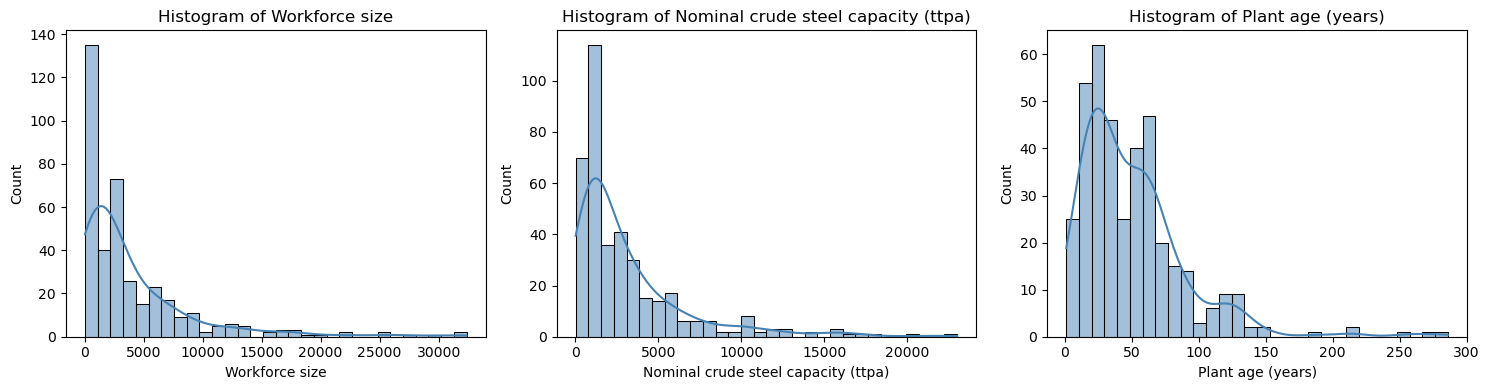

In [579]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to plot
columns_to_plot = [
    "Workforce size",
    "Nominal crude steel capacity (ttpa)",
    "Plant age (years)"
]

# Create histograms
plt.figure(figsize=(15, 4))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(1, len(columns_to_plot), i)
    sns.histplot(crude_steel_plants[col], bins=30, kde=True, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    
plt.tight_layout()
plt.show()



### **Task 1.3 – Feature Engineering**
- Create at least two new variables that might improve model performance (e.g., “capacity per worker”, “energy efficiency”).  
- Encode categorical variables and standardize numeric ones.
- Bonus: you are free to use external socioeconomic or environmental data sources to enhance your feature set.

> *Markdown prompt:*  
Document your new feature(s). What business or operational insight do they represent?

---


In [580]:
# Capacity per Worker
crude_steel_plants['Capacity per Worker (ttpa per worker)'] = (
    crude_steel_plants['Nominal crude steel capacity (ttpa)'] / crude_steel_plants['Workforce size']
)

# Worker Efficiency per Plant Age
crude_steel_plants['Worker Efficiency per Plant Age'] = (
    crude_steel_plants['Capacity per Worker (ttpa per worker)'] / crude_steel_plants['Plant age (years)']
)

# Average Annual Growth (%) over 2019–2024
crude_steel_plants['Avg Annual Growth (%)'] = (
    crude_steel_plants[year_cols].pct_change(axis=1).mean(axis=1) * 100
)

In [581]:
# Identify categorical columns (object or category type)
categorical_cols = crude_steel_plants.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Identify numeric columns
numeric_cols = crude_steel_plants.select_dtypes(include=['number']).columns.tolist()
print("Numeric columns:", numeric_cols)

Categorical columns: ['Region']
Numeric columns: ['Plant age (years)', 'Workforce size', 'Nominal crude steel capacity (ttpa)', 'Nominal BOF steel capacity (ttpa)', 'Nominal EAF steel capacity (ttpa)', 'Nominal OHF steel capacity (ttpa)', 'Other/unspecified steel capacity (ttpa)', '2019', '2020', '2021', '2022', '2023', '2024', 'Capacity per Worker (ttpa per worker)', 'Worker Efficiency per Plant Age', 'Avg Annual Growth (%)']


In [582]:
# One-hot encode categorical variables
encoded_df = pd.get_dummies(crude_steel_plants[categorical_cols], drop_first=True)

# Drop original categorical columns and append encoded ones
crude_steel_plants_encoded = pd.concat(
    [crude_steel_plants.drop(columns=categorical_cols), encoded_df],
    axis=1
)

print(f"Shape after encoding: {crude_steel_plants_encoded.shape}")

Shape after encoding: (385, 22)


In [583]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Standardize all numeric columns
crude_steel_plants_encoded[numeric_cols] = scaler.fit_transform(crude_steel_plants_encoded[numeric_cols])

# Check result
crude_steel_plants_encoded[numeric_cols].head()

,Plant age (years),Workforce size,Nominal crude steel capacity (ttpa),Nominal BOF steel capacity (ttpa),Nominal EAF steel capacity (ttpa),Nominal OHF steel capacity (ttpa),Other/unspecified steel capacity (ttpa),2019,2020,2021,2022,2023,2024,Capacity per Worker (ttpa per worker),Worker Efficiency per Plant Age,Avg Annual Growth (%)
2,0.715667,-0.461019,-0.319934,-0.602702,0.933529,-0.051031,-0.159953,-0.346156,-0.387547,-0.327917,-0.334185,-0.347226,-0.349465,-0.146261,-0.135838,-0.024970
3,-1.072698,-0.624882,-0.707673,-0.602702,-0.200493,-0.051031,-0.159953,-0.499922,-0.487910,-0.498366,-0.467840,-0.469875,-0.486308,-0.252159,0.016436,0.685710
4,0.366306,-0.193006,-0.400354,-0.602702,0.698324,-0.051031,-0.159953,-0.382744,-0.404762,-0.390453,-0.376181,-0.378547,-0.387536,-0.317757,-0.147591,-0.190661
5,0.363031,-0.137993,0.111174,0.371951,-0.746504,-0.051031,-0.159953,-0.171130,-0.240088,-0.180073,-0.151534,-0.161603,-0.180880,-0.188607,-0.134340,-0.193082
6,1.169055,-0.191635,0.024723,0.288155,-0.746504,-0.051031,-0.159953,-0.030879,0.003837,0.002917,0.006619,-0.005201,-0.003290,-0.189304,-0.143816,-0.159237



## 1.4 Feature Relationships and Correlations
*Estimated time: 20–25 min*

### Objective  
Before training models, it’s essential to understand how features relate to each other and to the target variable — both linearly and nonlinearly. This helps identify redundant or uninformative predictors and guides model choice.

---

### **Task 1.4.1 – Correlation Matrix (Linear Relationships)**
- Compute a **correlation matrix** (e.g., using `df.corr()`, `seaborn.heatmap`, `skrub`) to examine pairwise linear relationships among numerical features.  
- Focus on correlations between each feature and the target (`production`), as well as between features themselves.

> *Markdown prompt:*  
Which variables show the strongest correlation with production?  
Do any features appear redundant or highly correlated with each other?

---


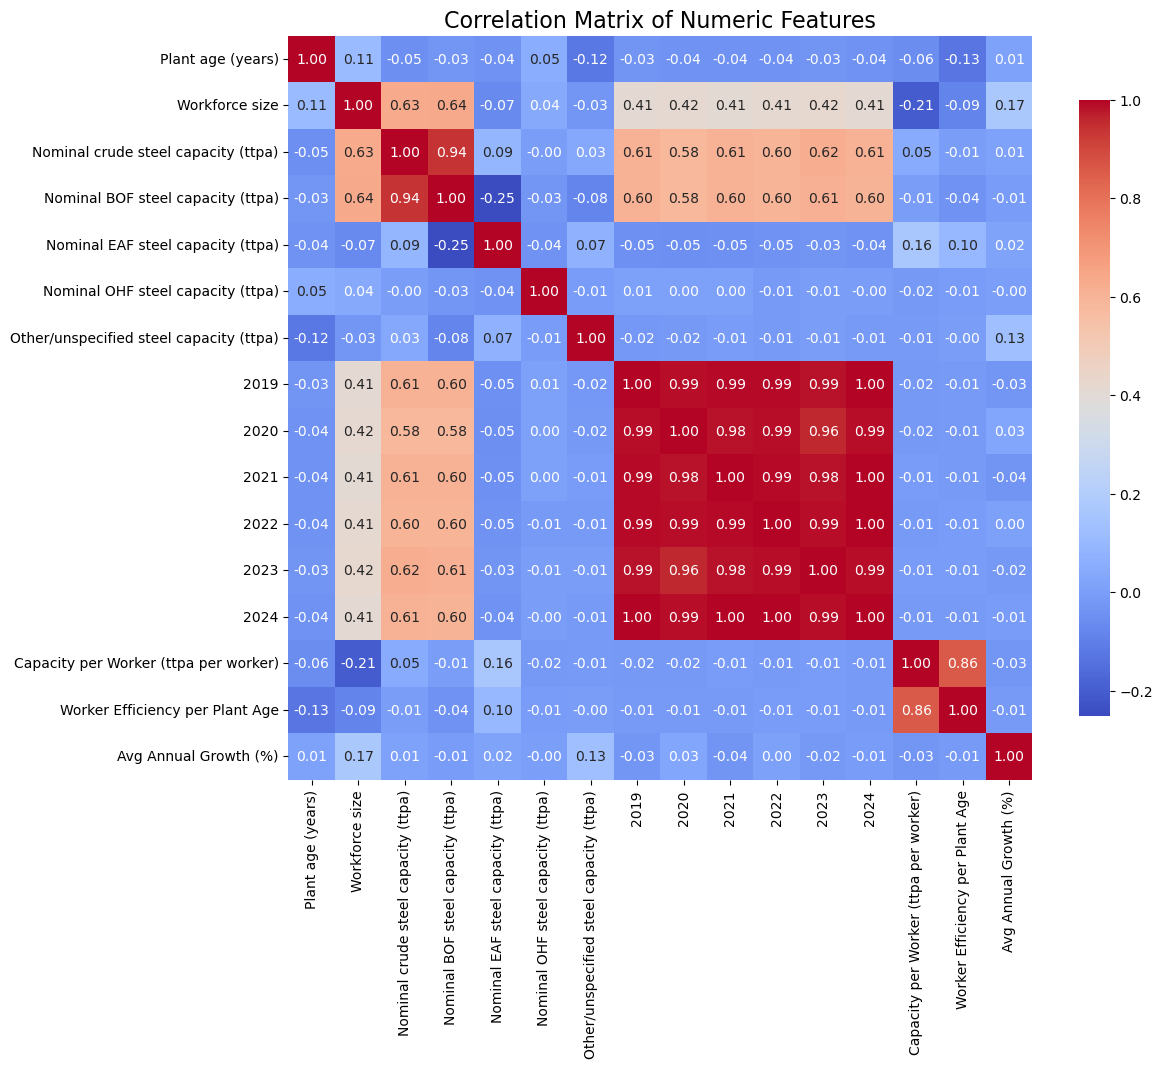

In [584]:
# Select numeric columns
numeric_cols = crude_steel_plants.select_dtypes(include=['number']).columns.tolist()

# Compute Pearson correlation
corr_matrix = crude_steel_plants[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation coefficients
    fmt=".2f",         # 2 decimals
    cmap="coolwarm",   # blue-red color map
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

## 2. Building Baseline & Linear Models
⏱ *Estimated time: 25–30 min*

### Objective  
Establish a simple baseline, then train and interpret a linear model.

---

### **Task 2.1 – Baseline**
- Compute a simple baseline predictor (e.g., mean or median production).  
- Measure RMSE or MAE compared to actual values.

> *Markdown prompt:*  
Why is it useful to have a baseline model before trying more complex ones?

---


In [585]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Target year
target_year = "2024"
past_years = ["2019", "2020", "2021", "2022", "2023"]

# Baseline: mean of previous years for each plant
baseline_value = crude_steel_plants[past_years].mean(axis=1)

# Predicted values
predicted = baseline_value.values

# Actual values
actual = crude_steel_plants[target_year].values

# Compute RMSE and MAE
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print(f"{target_year} - Baseline prediction (mean of previous years)")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")

2024 - Baseline prediction (mean of previous years)
RMSE: 109.31, MAE: 8.85



### **Task 2.2 – Linear Regression**
- Train a multiple linear regression model using the key plant variables.  
- Display coefficients and interpret their meaning.  
- Evaluate the model on training and test data.

> *Markdown prompt:*  
Interpret one positive and one negative coefficient. What do they tell you about plant performance drivers?

---


In [586]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Target variable (e.g., 2024 production)
y = crude_steel_plants['2019']

# Predictor variables (numeric + engineered features)
feature_cols = [
    'Plant age (years)',
    'Workforce size',
    'Nominal crude steel capacity (ttpa)',
    'Nominal BOF steel capacity (ttpa)',
    'Nominal EAF steel capacity (ttpa)',
    'Nominal OHF steel capacity (ttpa)',
    'Other/unspecified steel capacity (ttpa)',
    'Capacity per Worker (ttpa per worker)',
    'Avg Annual Growth (%)',
    'Worker Efficiency per Plant Age'
]

X = crude_steel_plants[feature_cols]

In [587]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [588]:
# Initialize and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [589]:
# Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
})

print("Linear Regression Coefficients:")
display(coef_df)

Linear Regression Coefficients:


,Feature,Coefficient
0,Plant age (years),-2.590292e+00
1,Workforce size,-1.718162e-02
2,Nominal crude steel capacity (ttpa),5.587266e-01
3,Nominal BOF steel capacity (ttpa),5.023912e-01
4,Nominal EAF steel capacity (ttpa),1.958151e-01
5,Nominal OHF steel capacity (ttpa),1.421085e-13
6,Other/unspecified steel capacity (ttpa),-1.394798e-01
7,Capacity per Worker (ttpa per worker),-1.677706e+02
8,Avg Annual Growth (%),-8.697425e+00
9,Worker Efficiency per Plant Age,4.367158e+02


In [590]:
# Training error
train_rmse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Test error
test_rmse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Training RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")

Training RMSE: 14640168.01, MAE: 1122.25
Test RMSE: 55697855.51, MAE: 1723.21


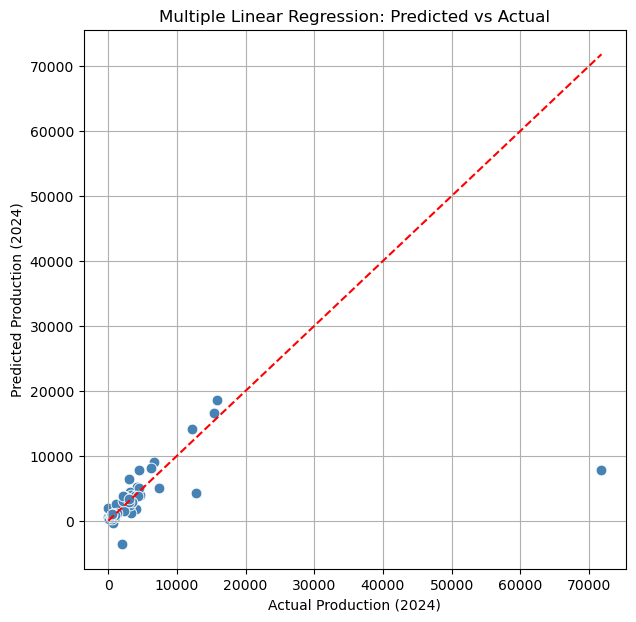

In [591]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted vs Actual (Test Set)
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_test_pred, color='steelblue', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.xlabel("Actual Production (2024)")
plt.ylabel("Predicted Production (2024)")
plt.title("Multiple Linear Regression: Predicted vs Actual")
plt.grid(True)
plt.show()

## 3. Model Evaluation and Selection
*Estimated time: 45–60 min*

### Objective  
Use cross-validation to estimate generalization performance and compare multiple model types.

---

### **Task 3.1 – Cross-Validation**
- Apply **K-Fold cross-validation** (e.g., K=5).  
- Record the average RMSE, MAE, and R² across folds.

> *Markdown prompt:*  
Summarize your results. How stable is performance across folds? What might this indicate about model variance?

---


### **Task 3.2 – Model Comparison**
Train and compare at least **three models**:
- Linear Regression  
- Ridge Regression (regularized linear)  
- Random Forest Regressor  

Record cross-validation performance for each model.

> *Markdown prompt:*  
Create a small results table. Which model performs best? Why might that be the case given the dataset’s characteristics?

---

### **Task 3.3 – Hyperparameter Optimization**
- Use **RandomizedSearchCV** or **GridSearchCV** to tune the top model (e.g., Random Forest).  
- Report the best parameters and corresponding validation score.

> *Markdown prompt:*  
Discuss the role of hyperparameter tuning. How did tuning change your model’s performance compared to default settings?

---


## 4. Model Lifecycle: Tracking, Saving, and Loading
*Estimated time: 30–40 min*

### Objective  
Apply tools that support reproducible ML experiments.

---

### **Task 4.1 – Experiment Tracking with MLflow**
- Use MLflow to log parameters (model type, hyperparameters), metrics (RMSE, R²), and artifacts (plots or model files).  
- Run and record at least two model experiments.

> *Markdown prompt:*  
Describe how MLflow helps manage your experiments. What advantages does it give compared to manual tracking?

---

### **Task 4.2 – Hyperparameter Optimization with Optuna**
- Define an Optuna study to optimize one model (e.g., Ridge or Random Forest).  
- Record the number of trials and best result.

> *Markdown prompt:*  
Explain what Optuna is doing behind the scenes. How is it different from Grid or Random Search?

---

### **Task 4.3 – Model Storage**
- Save the best performing model to a file (e.g., using joblib or MLflow’s model registry).  
- Demonstrate loading the saved model and re-evaluating it on the test set.

> *Markdown prompt:*  
Why is it important to store both model parameters and metadata? How would you ensure version control of models in a production setting?

---


## 5. Deployment & Monitoring (Conceptual)
*Estimated time: 15–20 min*

### Objective  
Reflect on how models transition from training to production and stay reliable over time.

---

### **Task 5.1 – Deployment Planning**
> *Markdown prompt:*  
Describe how you would deploy your model in a business environment (e.g., via REST API, batch pipeline).  
Which metrics would you monitor in production?

---

### **Task 5.2 – Detecting Model Drift**
> *Markdown prompt:*  
What signs might indicate your model needs retraining?  
Give one example of **data drift** and one of **concept drift** relevant to steel plant production.

---

## 6. Reflection
*Estimated time: 10–15 min*

> *Markdown prompt:*  
1. Which step of the modelling lifecycle did you find most challenging and why?  
2. What would you do differently if you had access to additional plant-level data?  
3. How would you communicate model insights to a business audience?

---

**End of Lab**

Next week: Short quiz on theoretical concepts (distributions, regression, model selection, and experiment tracking).

